# Example 1: Streamflow Forecasting (Experiment 1)

Mirrors the paper's Experiment 1: hourly streamflow forecasting at withheld basins, using observed
(perfect-foresight) future meteorological forcing, at lead times up to 240 h.

**Case study**: basin `13018300` (Cache Creek near Jackson, WY) -- selected as the highest-median-NSE
basin with full lead-time coverage in the paper's own Experiment 1 evaluation (see
`Paper_visualization/SM_F17_case_study_nse_by_lead.ipynb`). This notebook runs 30 forecast cycles
spread across the 2025 evaluation year and reports NSE **at each lead time**, pooled across those
30 cycles, rather than a single pooled scalar -- producing the full lead-time degradation curve.

Data: `data/exp1_streamflow/13018300.csv` -- 2 years of hourly CAMELSH forcing + streamflow
(11 forcing variables + `Streamflow`, area-normalized to mm/day); 2024 provides the trailing context
for origins issued during the 2025 evaluation year.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.pipeline import HydroORBITPipeline

WEIGHTS_DIR = REPO_ROOT / "weights"
pipe = HydroORBITPipeline.from_pretrained(str(WEIGHTS_DIR))
print("Loaded HydroORBIT on device:", pipe.device)

FORCING_COLS = ["Tair", "Qair", "PSurf", "Wind_E", "Wind_N", "LWdown",
                "CRainf_frac", "CAPE", "PotEvap", "Rainf", "SWdown"]

def nse(obs, sim, min_samples=24):
    """Nash-Sutcliffe efficiency, pooled across whatever (obs, sim) pairs are given.
    Returns NaN below min_samples or when the observed variance is degenerate
    (near-constant obs), matching the guard used for the paper's own metrics."""
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) < min_samples:
        return np.nan
    den = np.sum((obs - obs.mean()) ** 2)
    scale = max(abs(obs.mean()), 1.0)
    if den <= (1e-10 * scale) ** 2 * len(obs):
        return np.nan
    return 1.0 - np.sum((sim - obs) ** 2) / den


def origins_for_eval_year(index, year, context_len, horizon):
    """Positions in `index` that fall within `year` and have enough trailing
    context (context_len) and enough remaining data (horizon) around them."""
    positions = np.where(index.year == year)[0]
    positions = positions[(positions >= context_len) & (positions + horizon <= len(index))]
    return positions


Loaded HydroORBIT on device: mps


In [2]:
BASIN = "13018300"
CONTEXT_LEN = 8760      # 1 year of hourly context
HORIZON = 240             # 10-day forecast, matching the paper's longest lead time
N_ORIGINS = 50             # forecast cycles spread across the 2025 evaluation year -- this
                            # basin's real record has ~23% missing hours, so extra origins
                            # keep the per-lead sample count safely above the min-sample floor
EVAL_YEAR = 2025

df = pd.read_csv(f"data/exp1_streamflow/{BASIN}.csv", index_col="datetime", parse_dates=True)
print(df.shape, df.index.min(), "->", df.index.max())
df.tail()


(17544, 12) 2024-01-01 00:00:00 -> 2025-12-31 23:00:00


,Tair,Qair,PSurf,Wind_E,Wind_N,LWdown,CRainf_frac,CAPE,PotEvap,Rainf,SWdown,Streamflow
datetime,,,,,,,,,,,,
2025-12-31 19:00:00,1.890009,0.003473,77014.4,0.72,2.28,212.14,0.0,0.0,0.0524,0.0,377.755,NaN
2025-12-31 20:00:00,2.360010,0.003637,76953.7,0.55,2.05,212.13,0.0,0.0,0.0524,0.0,372.493,NaN
2025-12-31 21:00:00,2.830011,0.003801,76893.1,0.38,1.83,214.97,0.0,0.0,0.0524,0.0,302.767,NaN
2025-12-31 22:00:00,1.659998,0.003276,76830.4,0.49,2.27,214.99,0.0,0.0,0.0290,0.0,222.674,NaN
2025-12-31 23:00:00,0.490015,0.002751,76767.7,0.61,2.71,215.01,0.0,0.0,0.0290,0.0,111.081,NaN


In [3]:
positions = origins_for_eval_year(df.index, EVAL_YEAR, CONTEXT_LEN, HORIZON)
origins = positions[np.linspace(0, len(positions) - 1, N_ORIGINS).astype(int)]

runs = []
for origin in origins:
    ctx_slice = df.iloc[origin - CONTEXT_LEN:origin]
    fut_slice = df.iloc[origin:origin + HORIZON]
    target = ctx_slice["Streamflow"].to_numpy(np.float32)
    forcing = ctx_slice[FORCING_COLS].to_numpy(np.float32)
    future_forcing = fut_slice[FORCING_COLS].to_numpy(np.float32)
    observed_future = fut_slice["Streamflow"].to_numpy(np.float32)

    out = pipe.predict(target, forcing=forcing, future_forcing=future_forcing, prediction_length=HORIZON)
    median = out.median[0].numpy()
    q10 = out.quantile_preds[0, (out.quantile_levels - 0.1).abs().argmin()].numpy()
    q90 = out.quantile_preds[0, (out.quantile_levels - 0.9).abs().argmin()].numpy()
    runs.append({
        "issue_time": df.index[origin], "observed": observed_future,
        "median": median, "q10": q10, "q90": q90,
    })
print(f"Ran {len(runs)} forecast cycles across {EVAL_YEAR}.")


Ran 50 forecast cycles across 2025.


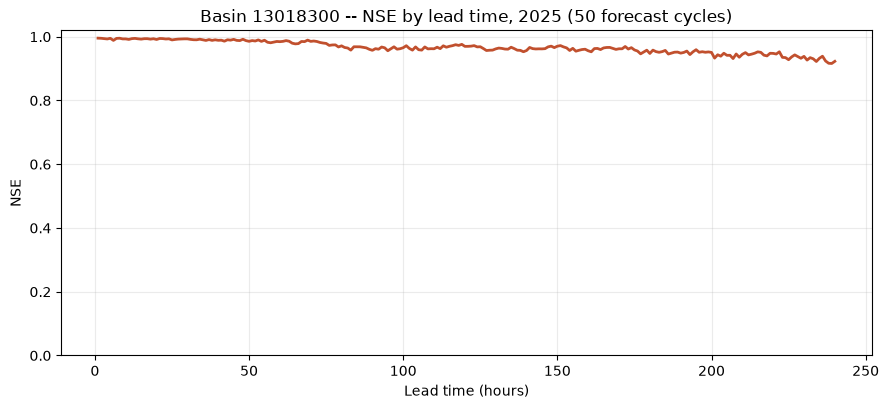

Median NSE across all leads: 0.965  (lead 1h: 0.995, lead 240h: 0.923)


In [4]:
# NSE PER LEAD, pooled across all 30 origins at that lead -- not pooled across
# leads. This is the "NSE for the whole lead time" curve: at each lead h, we
# gather the (observed, predicted) pair from every one of the 30 forecast
# cycles and score them together, then move to the next lead.
obs_stack = np.stack([r["observed"] for r in runs])   # (N_ORIGINS, HORIZON)
sim_stack = np.stack([r["median"] for r in runs])
lead_h = np.arange(1, HORIZON + 1)
nse_by_lead = np.array([nse(obs_stack[:, h], sim_stack[:, h]) for h in range(HORIZON)])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(lead_h, nse_by_lead, color="#C1502E", linewidth=2.0)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Lead time (hours)")
ax.set_ylabel("NSE")
ax.set_title(f"Basin {BASIN} -- NSE by lead time, {EVAL_YEAR} ({N_ORIGINS} forecast cycles)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print(f"Median NSE across all leads: {np.nanmedian(nse_by_lead):.3f}  "
      f"(lead 1h: {nse_by_lead[0]:.3f}, lead {HORIZON}h: {nse_by_lead[-1]:.3f})")
